# Gaussiana Multivariada - Resumen y Ejercicios

## 1. Conceptos Fundamentales

### Definición
Un **vector gaussiano** $X = (X_1, \dots, X_n)$ es un vector aleatorio donde:
- **Vector de medias**: $\mu = (\mu_1, \dots, \mu_n)$
- **Matriz de covarianzas**: $\Sigma = (Cov(X_i, X_j))_{i,j}$

### Propiedades Clave

| Propiedad | Descripción |
|-----------|-------------|
| **1** | Cada componente $X_i$ es una variable aleatoria **gaussiana** (normal) |
| **2** | Si las componentes son **independientes** y gaussianas $\rightarrow$ el vector es gaussiano |
| **3** | Si $\mu \in \mathbb{R}^n$ y $\Sigma$ es **simétrica y positiva-definida** $\rightarrow$ **existe** un vector gaussiano con esos parámetros |

## 2. Función de Densidad

$$f(x;\mu, \Sigma)= \frac{1}{\sqrt{(2\pi)^{n} \det(\Sigma) }}\exp\left(-\frac{1}{2}(x-\mu)^{T}\Sigma^{-1}(x-\mu) \right)$$

### Componentes:
- **$\det(\Sigma)$**: Determinante de la matriz de covarianzas
- **$\Sigma^{-1}$**: Matriz inversa de covarianzas
- **$(x-\mu)^T \Sigma^{-1} (x-\mu)$**: Distancia de Mahalanobis al cuadrado

## 3. Importación de Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

## 4. Función de Densidad Bivariada

In [2]:
def gaussiana_bivariada(pss, mu, Sigma):
    """
    Calcula la densidad de una Gaussiana bivariada.

    Parámetros:
    pss: array de puntos (x, y)
    mu: vector de medias
    Sigma: matriz de covarianzas

    Retorna:
    array: valores de densidad
    """
    n = mu.shape[0]
    Sigma_det = np.linalg.det(Sigma)
    Sigma_inv = np.linalg.inv(Sigma)
    N = np.sqrt((2*np.pi)**n * Sigma_det)

    fac = np.einsum('...k,kl,...l->...', pss - mu, Sigma_inv, pss - mu)

    return np.exp(-fac / 2) / N

## 5. Visualización de Gaussiana Bivariada

### Parámetros:
- $\mu = (0, 1)$
- $\Sigma = \begin{pmatrix} 1 & -0.5 \\ -0.5 & 1.5 \end{pmatrix}$

In [3]:
# Crear malla de puntos
X = np.linspace(-3, 3, 50)
Y = np.linspace(-3, 4, 50)
X, Y = np.meshgrid(X, Y)

# Parámetros de la Gaussiana
mu = np.array([0., 1.])
Sigma = np.array([[1., -0.5], [-0.5, 1.5]])

print("Matriz de covarianzas:")
print(Sigma)
print(f"\nDeterminante: {np.linalg.det(Sigma):.4f}")
print(f"Inversa:\n{np.linalg.inv(Sigma)}")

Matriz de covarianzas:
[[ 1.  -0.5]
 [-0.5  1.5]]

Determinante: 1.2500
Inversa:
[[1.2 0.4]
 [0.4 0.8]]


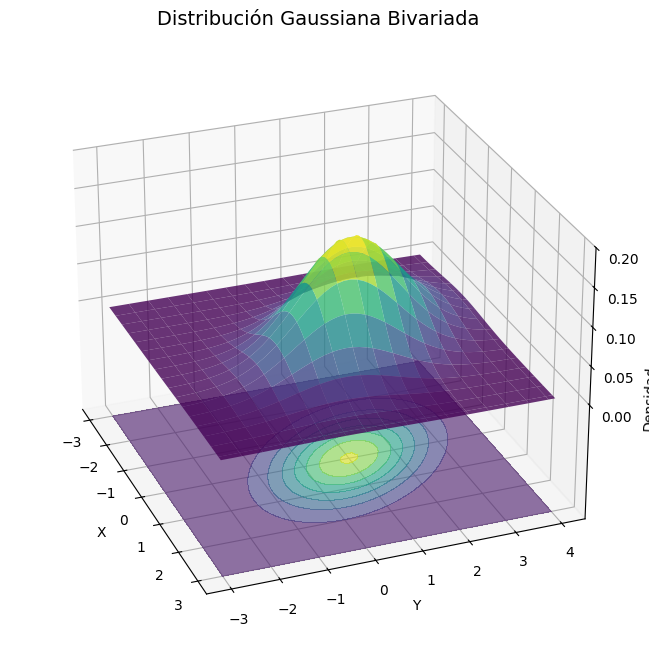

In [5]:
# Preparar puntos para la densidad
ps = np.empty(X.shape + (2,))
ps[:, :, 0] = X
ps[:, :, 1] = Y

# Calcular densidad
Z = gaussiana_bivariada(ps, mu, Sigma)

# Graficar
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Superficie 3D
ax.plot_surface(X, Y, Z, rstride=3, cstride=3, linewidth=1, antialiased=True,
                cmap=cm.viridis, alpha=0.8)

# Contornos
cset = ax.contourf(X, Y, Z, zdir='z', offset=-0.15, cmap=cm.viridis, alpha=0.6)

# Configuración
ax.set_zlim(-0.15, 0.2)
ax.set_zticks(np.linspace(0, 0.2, 5))
ax.view_init(27, -21)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Densidad')
ax.set_title('Distribución Gaussiana Bivariada', fontsize=14)

plt.show()

## 6. Muestreo de Gaussiana Trivariada

### Parámetros:
- $\mu = (2, -3, 1)$
- $\Sigma = \begin{pmatrix} 1 & 1 & 1 \\ 1 & 3 & 2 \\ 1 & 2 & 2 \end{pmatrix}$

In [6]:
# Parámetros
m = [2, -3, 1]
C = [[1, 1, 1], [1, 3, 2], [1, 2, 2]]

# Generar muestras
x, y, z = np.random.multivariate_normal(m, C, size=500).T

# Crear DataFrame
d = {"x": x, "y": y, "z": z}
df = pd.DataFrame(data=d)

print("Primeras 5 muestras:")
display(df.head())
print(f"\nMedia muestral: {df.mean().values}")
print(f"Covarianza muestral:\n{df.cov().values}")

Primeras 5 muestras:


,x,y,z
0,1.951696,-2.495626,0.627195
1,2.098480,-5.105007,-0.649869
2,3.543694,-1.692671,1.898994
3,2.569881,-2.454758,1.183936
4,2.770795,-2.370234,3.049157



Media muestral: [ 2.06953437 -2.94432517  1.07501212]
Covarianza muestral:
[[0.95821947 0.97617414 0.9809817 ]
 [0.97617414 3.01156411 2.07752557]
 [0.9809817  2.07752557 2.0877589 ]]


<Figure size 1000x800 with 0 Axes>

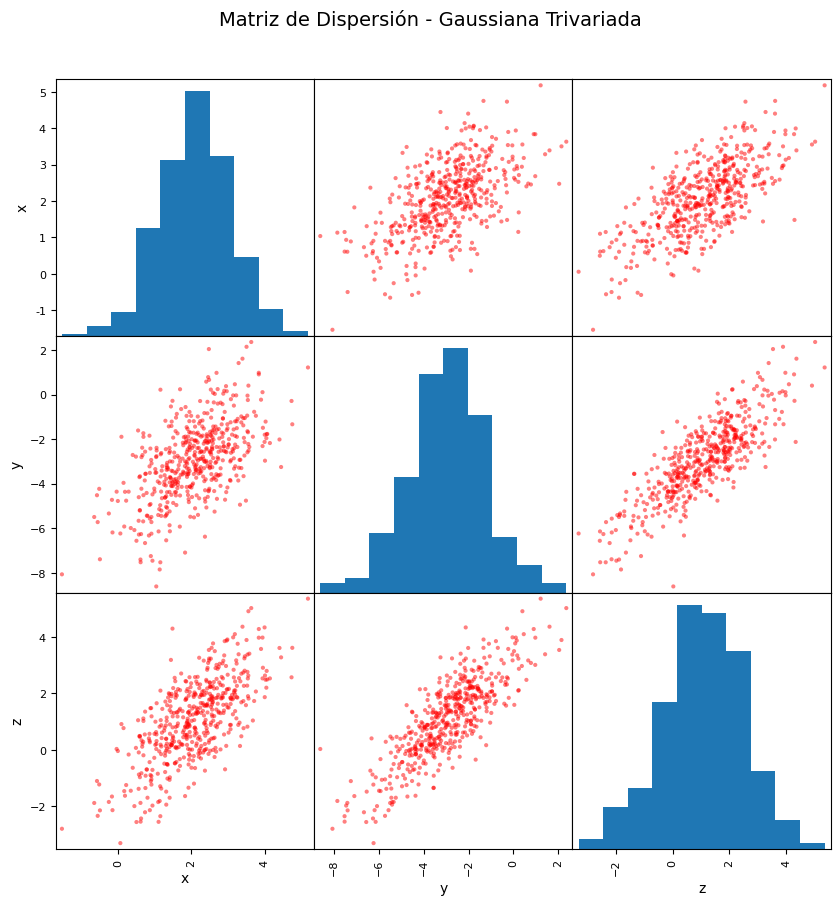

In [7]:
# Matriz de dispersión
fig = plt.figure(figsize=(10, 8))
pd.plotting.scatter_matrix(df, color="red", alpha=0.5, figsize=(10, 10))
plt.suptitle('Matriz de Dispersión - Gaussiana Trivariada', fontsize=14, y=0.95)
plt.show()

## 7. Distribución Normal Unidimensional

### Clase Gaussian

In [8]:
class Gaussian:
    '''
    Clase para la distribución Gaussiana unidimensional.
    '''
    def __init__(self, mu=0, sigma=1):
        self.mu, self.sigma = mu, sigma

    def densidad(self, x):
        """
        Calcula la densidad de la Gaussiana en x.
        """
        return (2*np.pi*self.sigma**2)**(-.5) * np.exp(-.5 * ((x - self.mu)/self.sigma)**2)

    def estimacion(self, x):
        """
        Estima los parámetros por máxima verosimilitud.
        """
        self.mu, self.sigma = np.mean(x), np.std(x)

    def muestra(self, n):
        """
        Genera n muestras de la Gaussiana.
        """
        x = np.random.randn(n)
        x = self.mu + self.sigma * x
        return x

### Visualización de Diferentes Gaussianas

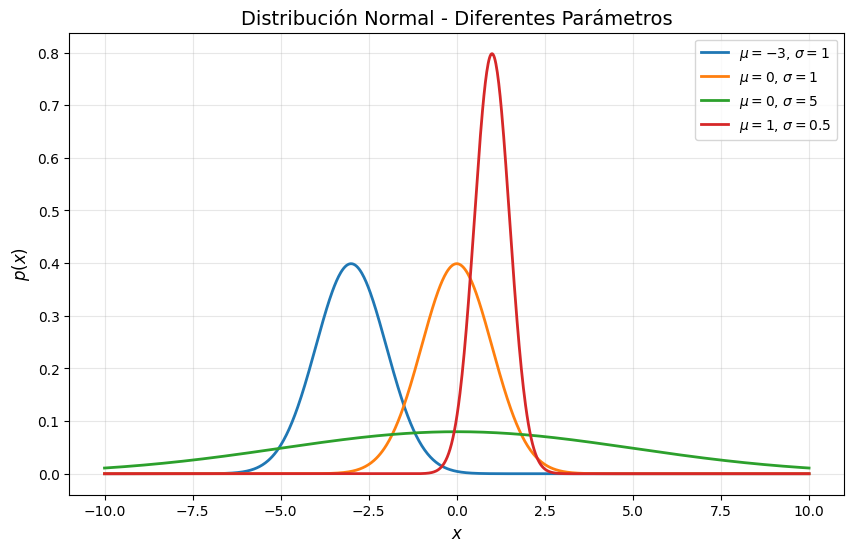

In [9]:
gaussian = Gaussian()
x_vals = np.linspace(-10, 10, 1000)
params = [(-3, 1), (0, 1), (0, 5), (1, 0.5)]

plt.figure(figsize=(10, 6))

for mu, sigma in params:
    gaussian.mu, gaussian.sigma = mu, sigma
    p_vals = gaussian.densidad(x_vals)
    plt.plot(x_vals, p_vals, label=f"$\\mu={mu}$, $\\sigma={sigma}$", linewidth=2)

plt.xlabel("$x$", fontsize=12)
plt.ylabel("$p(x)$", fontsize=12)
plt.legend()
plt.title("Distribución Normal - Diferentes Parámetros", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

## 8. Ejercicios Propuestos

### Ejercicio 1: Visualización Interactiva

Crea una función que permita visualizar la densidad de una Gaussiana bivariada para diferentes parámetros.

In [16]:
def visualizar_gaussiana_bivariada(mu, Sigma, titulo="Gaussiana Bivariada"):
    """
    Visualiza la densidad de una Gaussiana bivariada en 3D.

    Parámetros:
    mu: vector de medias [mu1, mu2]
    Sigma: matriz de covarianzas 2x2
    titulo: título del gráfico
    """
    # Convertir a arrays de NumPy si son listas
    mu = np.array(mu)
    Sigma = np.array(Sigma)

    # Crear malla
    x = np.linspace(mu[0]-4, mu[0]+4, 50)
    y = np.linspace(mu[1]-4, mu[1]+4, 50)
    X, Y = np.meshgrid(x, y)

    # Preparar puntos
    ps = np.empty(X.shape + (2,))
    ps[:, :, 0] = X
    ps[:, :, 1] = Y

    # Calcular densidad
    Z = gaussiana_bivariada(ps, mu, Sigma)

    # Graficar
    fig = plt.figure(figsize=(12, 5))

    # Subplot 1: Superficie 3D
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(X, Y, Z, cmap=cm.viridis, alpha=0.8)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Densidad')
    ax1.set_title('Superficie 3D')

    # Subplot 2: Contornos
    ax2 = fig.add_subplot(122)
    contour = ax2.contour(X, Y, Z, levels=10, cmap='viridis')
    ax2.clabel(contour, inline=True, fontsize=8)
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_title('Contornos de Densidad')
    ax2.grid(True, alpha=0.3)

    plt.suptitle(titulo, fontsize=14)
    plt.tight_layout()
    plt.show()

### Prueba del Ejercicio 1

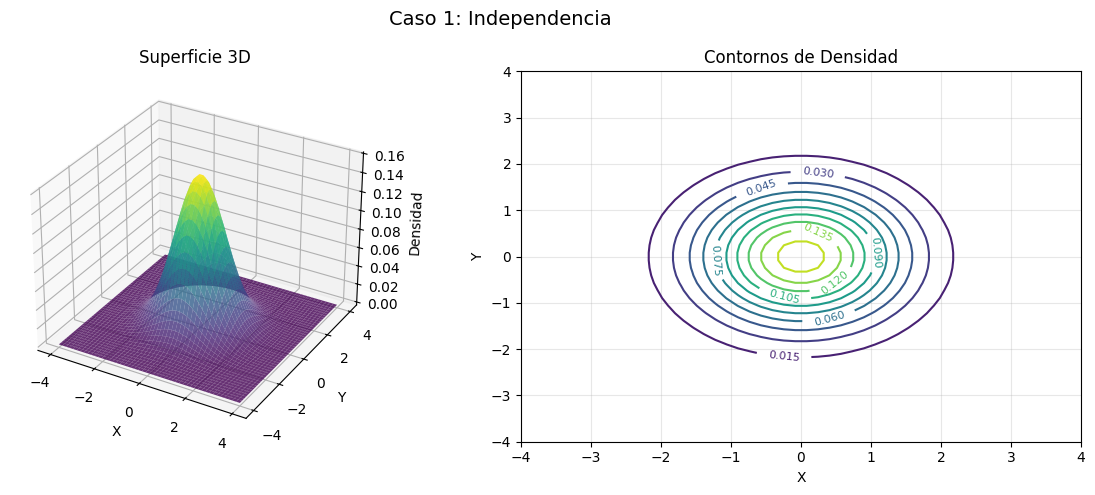

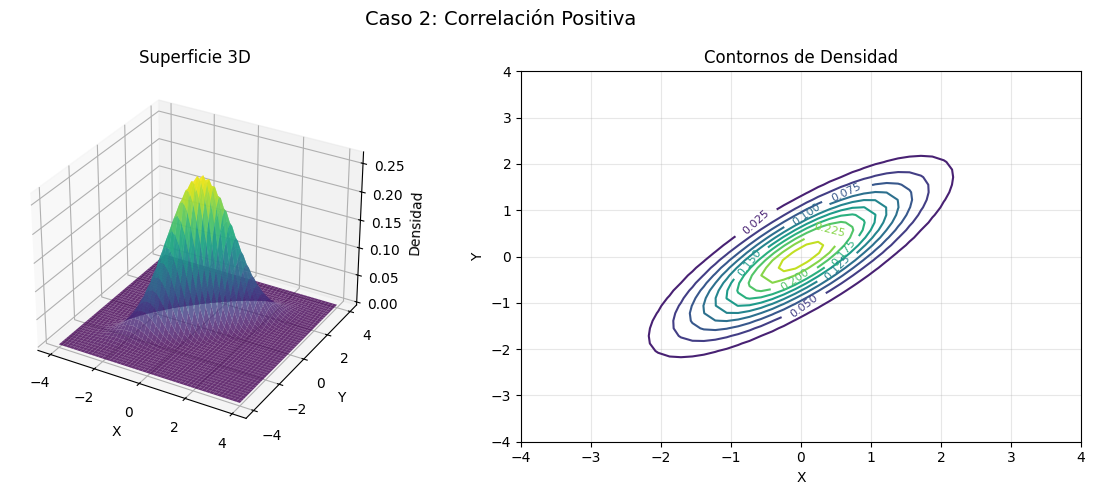

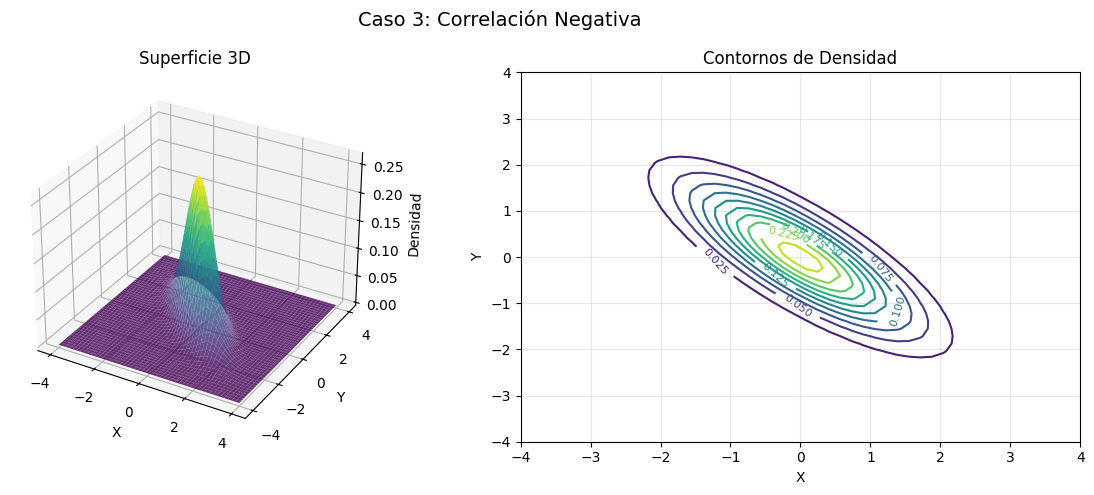

In [17]:
# Caso 1: Independencia
mu1 = [0, 0]
Sigma1 = [[1, 0], [0, 1]]
visualizar_gaussiana_bivariada(mu1, Sigma1, "Caso 1: Independencia")

# Caso 2: Correlación positiva
mu2 = [0, 0]
Sigma2 = [[1, 0.8], [0.8, 1]]
visualizar_gaussiana_bivariada(mu2, Sigma2, "Caso 2: Correlación Positiva")

# Caso 3: Correlación negativa
mu3 = [0, 0]
Sigma3 = [[1, -0.8], [-0.8, 1]]
visualizar_gaussiana_bivariada(mu3, Sigma3, "Caso 3: Correlación Negativa")

### Ejercicio 2: Estimación de Parámetros

Dado un conjunto de datos, estima $\mu$ y $\Sigma$ y compara con los parámetros reales.

In [18]:
# Datos reales
mu_real = [2, -1]
Sigma_real = [[2, 0.5], [0.5, 1]]

# Generar muestras
n_muestras = 1000
muestras = np.random.multivariate_normal(mu_real, Sigma_real, n_muestras)

# Estimar parámetros
mu_est = np.mean(muestras, axis=0)
Sigma_est = np.cov(muestras.T)

# Comparar
print("="*50)
print("COMPARACIÓN DE PARÁMETROS")
print("="*50)
print(f"\nMedia real:     {mu_real}")
print(f"Media estimada:  {mu_est}")
print(f"Error:           {np.linalg.norm(mu_real - mu_est):.4f}")

print(f"\nCovarianza real:")
print(Sigma_real)
print(f"\nCovarianza estimada:")
print(Sigma_est)
print(f"\nError Frobenius: {np.linalg.norm(Sigma_real - Sigma_est):.4f}")

COMPARACIÓN DE PARÁMETROS

Media real:     [2, -1]
Media estimada:  [ 1.89748063 -1.03403035]
Error:           0.1080

Covarianza real:
[[2, 0.5], [0.5, 1]]

Covarianza estimada:
[[2.11776197 0.46127395]
 [0.46127395 0.95004773]]

Error Frobenius: 0.1391


### Ejercicio 3: Visualización de la Estimación

In [21]:
def comparar_gaussianas(mu1, Sigma1, mu2, Sigma2, titulo1="Real", titulo2="Estimada"):
    """
    Compara dos Gaussianas bivariadas visualmente.
    """
    # Convertir a arrays de NumPy
    mu1 = np.array(mu1)
    Sigma1 = np.array(Sigma1)
    mu2 = np.array(mu2)
    Sigma2 = np.array(Sigma2)

    # Crear malla
    x = np.linspace(-5, 5, 50)
    y = np.linspace(-5, 5, 50)
    X, Y = np.meshgrid(x, y)

    ps = np.empty(X.shape + (2,))
    ps[:, :, 0] = X
    ps[:, :, 1] = Y

    # Calcular densidades
    Z1 = gaussiana_bivariada(ps, mu1, Sigma1)
    Z2 = gaussiana_bivariada(ps, mu2, Sigma2)

    # Graficar
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Primera Gaussiana
    axes[0].contour(X, Y, Z1, levels=10, cmap='viridis')
    axes[0].set_title(titulo1)
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')
    axes[0].grid(True, alpha=0.3)

    # Segunda Gaussiana
    axes[1].contour(X, Y, Z2, levels=10, cmap='viridis')
    axes[1].set_title(titulo2)
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Y')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Comparación de Gaussianas Bivariadas', fontsize=14)
    plt.tight_layout()
    plt.show()

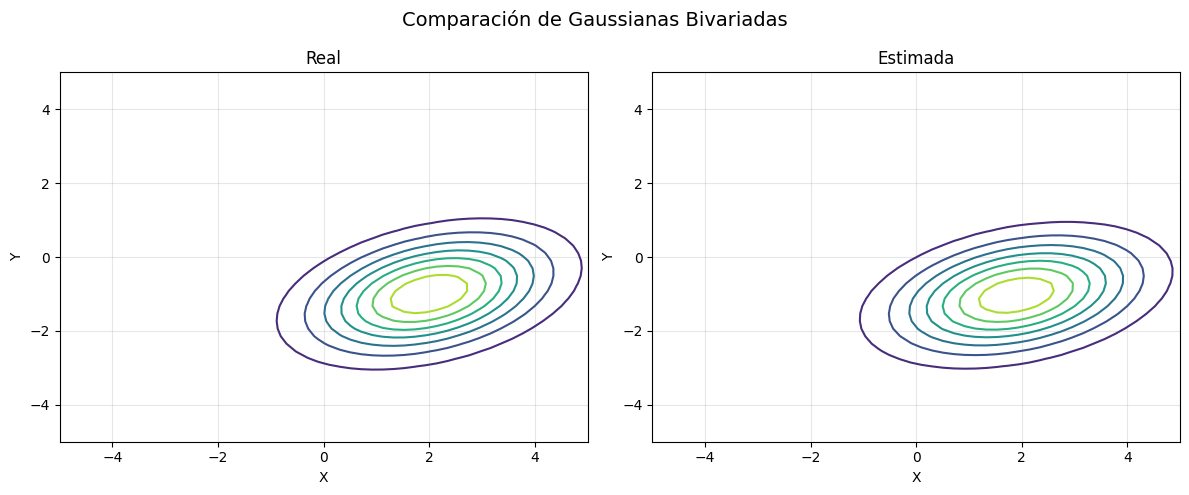

In [22]:
# Comparar Gaussiana real vs estimada
comparar_gaussianas(mu_real, Sigma_real, mu_est, Sigma_est)

### Ejercicio 4: Análisis de la Matriz de Covarianzas

Investiga cómo afectan los elementos de $\Sigma$ a la forma de la distribución.

In [25]:
def analizar_covarianza(rho):
    """
    Analiza el efecto del coeficiente de correlación rho.
    """
    # Convertir a arrays de NumPy
    mu = np.array([0, 0])
    Sigma = np.array([[1, rho], [rho, 1]])

    # Generar muestras
    muestras = np.random.multivariate_normal(mu, Sigma, 500)

    # Graficar
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Dispersión
    axes[0].scatter(muestras[:, 0], muestras[:, 1], alpha=0.5)
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')
    axes[0].set_title(f'Muestras ($\\rho={rho}$)')
    axes[0].grid(True, alpha=0.3)
    axes[0].axis('equal')

    # Contornos
    x = np.linspace(-4, 4, 50)
    y = np.linspace(-4, 4, 50)
    X, Y = np.meshgrid(x, y)
    ps = np.empty(X.shape + (2,))
    ps[:, :, 0] = X
    ps[:, :, 1] = Y
    Z = gaussiana_bivariada(ps, mu, Sigma)

    axes[1].contour(X, Y, Z, levels=10, cmap='viridis')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Y')
    axes[1].set_title(f'Contornos ($\\rho={rho}$)')
    axes[1].grid(True, alpha=0.3)
    axes[1].axis('equal')

    plt.suptitle('Efecto del Coeficiente de Correlación', fontsize=14)
    plt.tight_layout()
    plt.show()

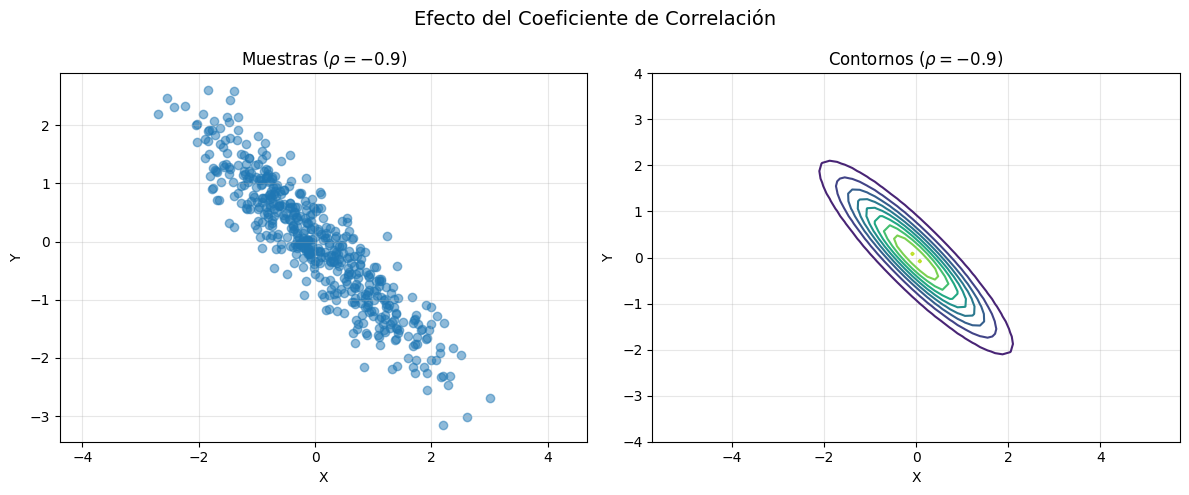

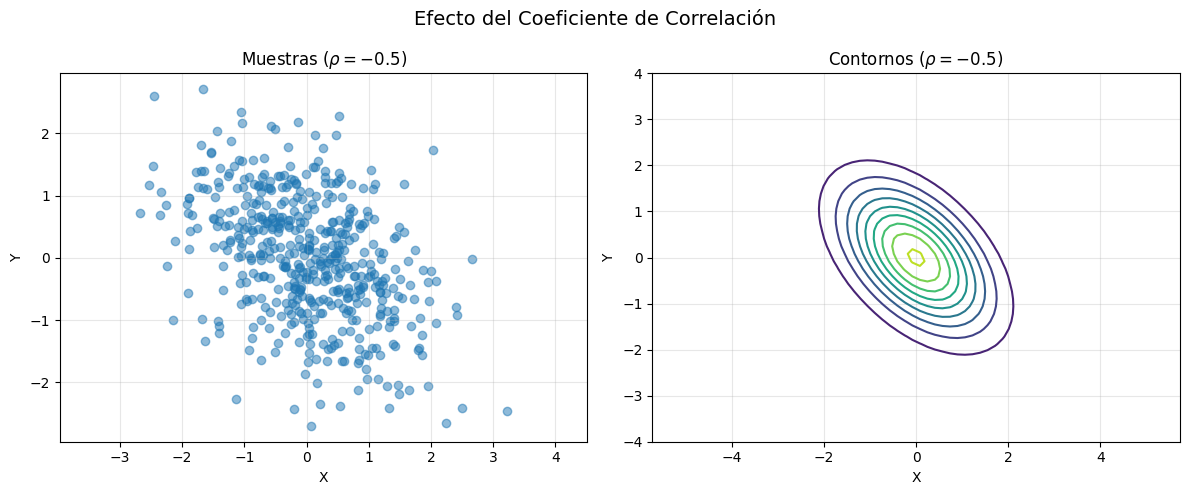

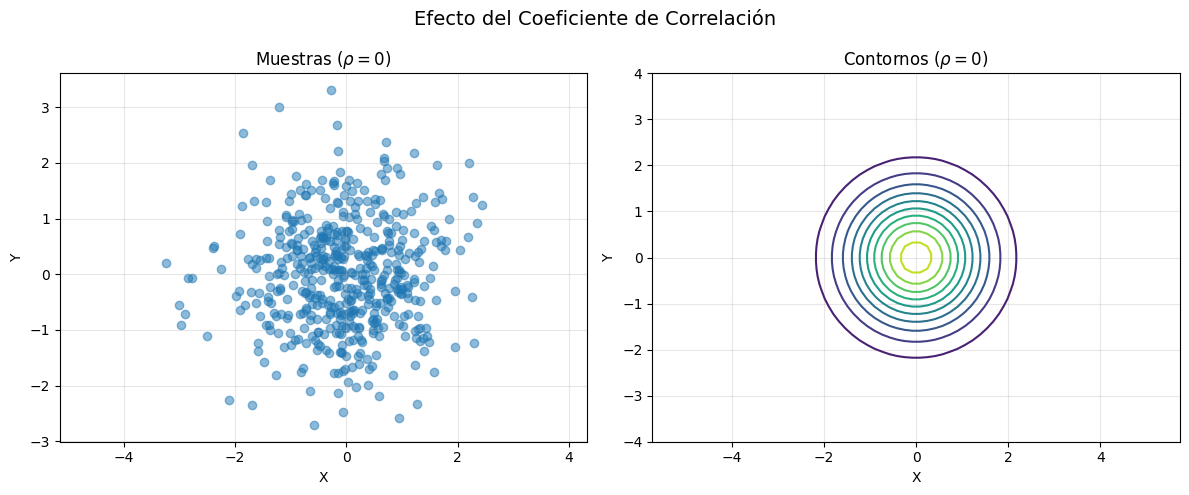

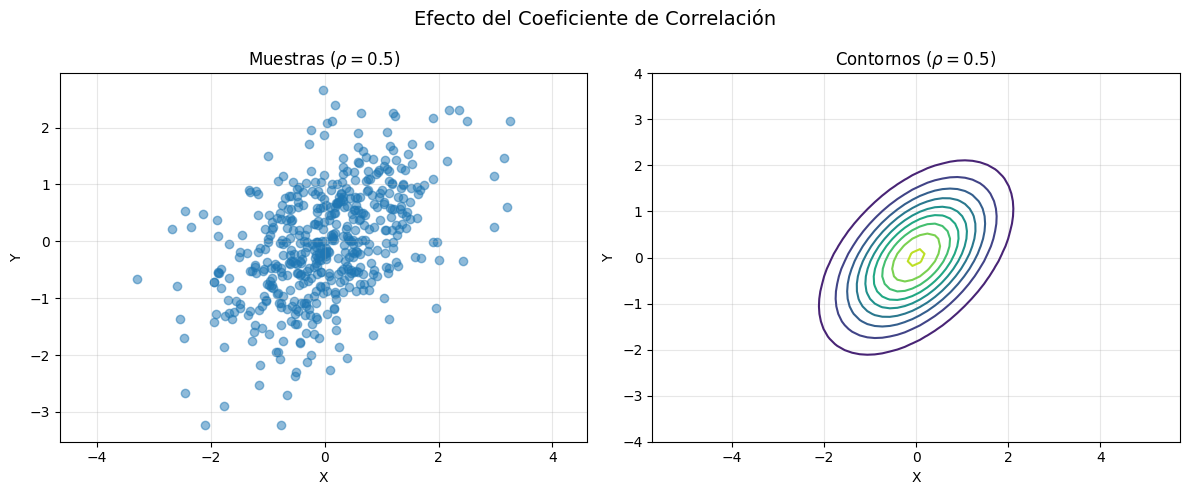

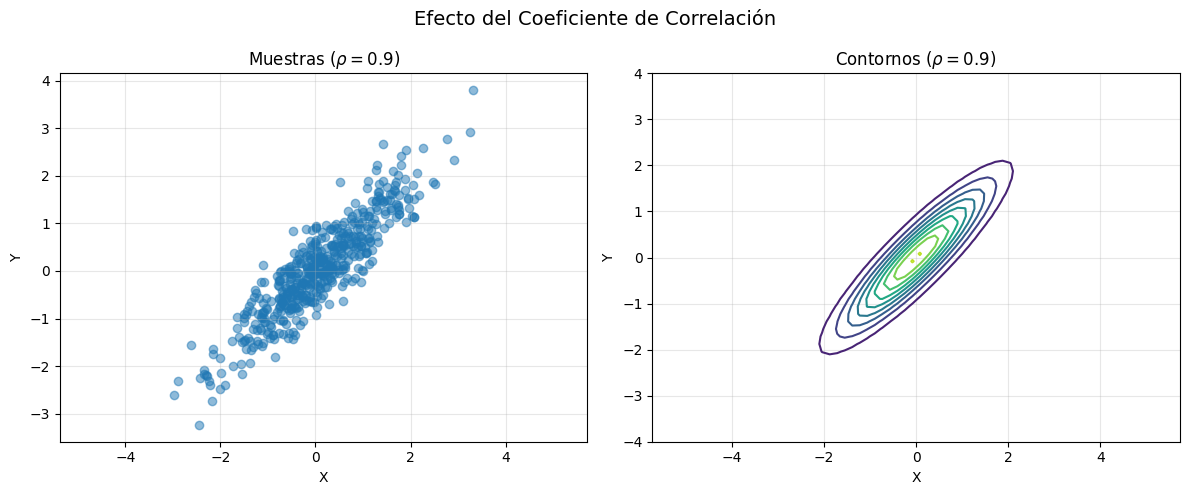

In [26]:
# Analizar diferentes correlaciones
for rho in [-0.9, -0.5, 0, 0.5, 0.9]:
    analizar_covarianza(rho)

## 9. Resumen de Resultados

### Propiedades de la Gaussiana Multivariada

| Propiedad | Descripción |
|-----------|-------------|
| **Linealidad** | Transformaciones lineales preservan normalidad |
| **Independencia** | Si $Cov(X_i, X_j) = 0$, las variables son independientes |
| **Marginales** | Cada componente es normal univariada |
| **Condicionales** | Las distribuciones condicionales son normales |
| **Teorema de existencia** | Para cualquier $\mu$ y $\Sigma$ SPD, existe un vector gaussiano |

### Interpretación de la Matriz de Covarianzas

$$\Sigma = \begin{pmatrix} \sigma_1^2 & \sigma_{12} \\ \sigma_{21} & \sigma_2^2 \end{pmatrix}$$

- **$\sigma_1^2$**: Varianza de la variable $X_1$
- **$\sigma_2^2$**: Varianza de la variable $X_2$
- **$\sigma_{12} = \sigma_{21}$**: Covarianza entre $X_1$ y $X_2$
- **$\rho = \frac{\sigma_{12}}{\sigma_1 \sigma_2}$**: Coeficiente de correlación

### Estimación de Máxima Verosimilitud

$$\hat{\mu} = \frac{1}{n} \sum_{i=1}^n x^{(i)}$$

$$\hat{\Sigma} = \frac{1}{n} \sum_{i=1}^n (x^{(i)} - \hat{\mu})(x^{(i)} - \hat{\mu})^T$$

## 10. Recursos y Bibliografía

### Librerías Utilizadas
- **NumPy**: Operaciones matriciales y generación de muestras
- **Matplotlib**: Visualizaciones 2D y 3D
- **Pandas**: Manejo y análisis de datos

### Temas Relacionados
- Distribución normal univariada
- Matriz de covarianzas
- Distancia de Mahalanobis
- Teorema Central del Límite
- Procesos Gaussianos

## ¡Felicidades!

Has completado el estudio de la **Gaussiana Multivariada**. Estos conceptos son fundamentales en:

- **Machine Learning**: Clasificadores Bayesianos, GMMs
- **Estadística**: Inferencia multivariada
- **Finanzas**: Modelos de riesgo
- **Señales**: Filtrado y procesamiento
- **Visión**: Reconocimiento de patrones

In [27]:
print("\n" + "="*60)
print("RESUMEN FINAL - GAUSSIANA MULTIVARIADA")
print("="*60)
print(f"\n1. La Gaussiana Multivariada es la generalización de la normal a n dimensiones.")
print(f"2. Parámetros: μ (media) y Σ (matriz de covarianzas SPD).")
print(f"3. La densidad depende de la distancia de Mahalanobis.")
print(f"4. Si las componentes son independientes, Σ es diagonal.")
print(f"5. La EMV estima μ y Σ a partir de los datos.")
print(f"6. La forma de los contornos refleja la estructura de correlación.")
print(f"\n" + "="*60)


RESUMEN FINAL - GAUSSIANA MULTIVARIADA

1. La Gaussiana Multivariada es la generalización de la normal a n dimensiones.
2. Parámetros: μ (media) y Σ (matriz de covarianzas SPD).
3. La densidad depende de la distancia de Mahalanobis.
4. Si las componentes son independientes, Σ es diagonal.
5. La EMV estima μ y Σ a partir de los datos.
6. La forma de los contornos refleja la estructura de correlación.

